In [7]:
pip install ultralytics supervision

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [supervision]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolo11n.pt")
# Train the model
model.train(
    data="/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/dataset/data.yaml",
    #data="dataset/data.yaml",  # Path to the YAML file
    epochs=70,  # Number of epochs
    imgsz=640,  # Image size
    project="runs_yolov11",  # Folder to save results
    name="food_detection_yolov11" # Model name
)




In [ ]:
import shutil
import os

# Create a folder in Google Drive to save the model
save_dir = "yolo_models"
os.makedirs(save_dir, exist_ok=True)

# Copy the best model (best.pt) to Google Drive
source_path = "runs_yolov11/food_detection_yolov11/weights/best.pt"
destination_path = os.path.join(save_dir, "food_yolov11_best.pt")
shutil.copy(source_path, destination_path)

# Copy the last model (last.pt) to Google Drive
source_path_last = "runs_yolov11/food_detection_yolov11/weights/last.pt"
destination_path_last = os.path.join(save_dir, "food_yolov11_last.pt")
shutil.copy(source_path_last, destination_path_last)

print(f"Model đã được lưu tại:\n- {destination_path}\n- {destination_path_last}")


Found https://img-global.cpcdn.com/recipes/2c630c584ca9709c/680x482cq70/bun-dậu-mắm-tom-recipe-main-photo.jpg locally at bun-dậu-mắm-tom-recipe-main-photo.jpg
image 1/1 /Users/admin/Documents/DL-DuDoan33MonAnVietNam/yolo/bun-dậu-mắm-tom-recipe-main-photo.jpg: 480x640 1 bun, 1 bun dau, 8 dau hus, 5 thit heos, 47.7ms
Speed: 5.1ms preprocess, 47.7ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


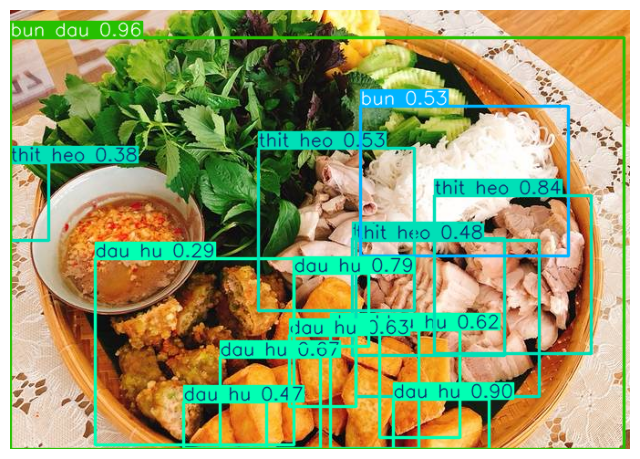

In [1]:
# show
%matplotlib inline
import matplotlib.pyplot as plt
from ultralytics import YOLO
model_path = "yolo_models/food_yolov11_best.pt"
# Load a pretrained YOLOv11 model (e.g., nano version for speed)
model = YOLO(model_path)

# Define the source image (can be a local path, URL, etc.)
source_image = 'https://img-global.cpcdn.com/recipes/2c630c584ca9709c/680x482cq70/bun-d%E1%BA%ADu-m%E1%BA%AFm-tom-recipe-main-photo.jpg' 

# Run inference on the image
results = model.predict(source=source_image)

# Display the results. The 'show()' method visualizes the image with bounding boxes.
# If you have multiple results (e.g., from a batch of images), you can iterate through them.
#results[0].show() 

annotated_image = results[0].plot()   # numpy array BGR

plt.figure(figsize=(8, 6))
plt.imshow(annotated_image[..., ::-1])  # đổi BGR → RGB cho chắc
plt.axis('off')
plt.show()

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt


source_image1= "https://images.baoangiang.com.vn/image/fckeditor/upload/2021/20210531/images/bun-nuoc-leo-soc-trang.jpg"
source_image2= 'https://mms.img.susercontent.com/vn-11134513-7ra0g-m8bk0wnpyjcyb7@resize_ss1242x600!@crop_w1242_h600_cT'
source_image3=  "https://i.ytimg.com/vi/y28pUEEjiw8/hq720.jpg?sqp=-oaymwEhCK4FEIIDSFryq4qpAxMIARUAAAAAGAElAADIQj0AgKJD&rs=AOn4CLD0HCuoITbynSGJxALzii_RxERm6Q"
source_image4="https://i.ytimg.com/vi/r03VeYGqOqg/maxresdefault.jpg"
'''
# Perform predictions on an image
results = model.predict(
    source=source_image,
    conf=0.5 , # Confidence threshold
    show=True
)
'''

# Run batched inference on a list of images
results = model([source_image1, source_image2,source_image3,source_image4])  # return a list of Results objects
# Process results list
for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    keypoints = result.keypoints  # Keypoints object for pose outputs
    probs = result.probs  # Probs object for classification outputs
    obb = result.obb  # Oriented boxes object for OBB outputs
    result.show()  # display to screen
    result.save(filename=source_image)  # save to disk

'''
annotated_image = results[0].plot()   # numpy array BGR
plt.figure(figsize=(8, 6))
plt.imshow(annotated_image[..., ::-1])  # đổi BGR → RGB cho chắc
plt.axis('off')
plt.show()
'''




0: 640x640 1 bun, 3 thit heo quays, 3 toms, 49.9ms
1: 640x640 1 bun, 2 toms, 1 trung, 49.9ms
2: 640x640 1 bun, 49.9ms
3: 640x640 1 bun hai san, 3 cas, 8 thit heo quays, 5 toms, 49.9ms
Speed: 2.0ms preprocess, 49.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


"\nannotated_image = results[0].plot()   # numpy array BGR\nplt.figure(figsize=(8, 6))\nplt.imshow(annotated_image[..., ::-1])  # đổi BGR → RGB cho chắc\nplt.axis('off')\nplt.show()\n"


image 1/1 /Users/admin/Documents/DL-DuDoan33MonAnVietNam/yolo/bun-bo-hue-2-0933.jpg: 448x640 1 bun, 37.2ms
Speed: 2.1ms preprocess, 37.2ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 640)


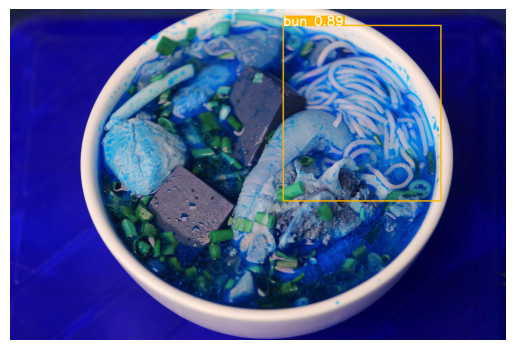

In [3]:
# Perform predictions on an image
results = model.predict(
    source='https://i2.ex-cdn.com/crystalbay.com/files/content/2024/08/15/bun-bo-hue-2-0933.jpg',
    conf=0.5  # Confidence threshold
)

# Get the image with bounding boxes annotated
annotated_image = results[0].plot()

# Display the image in Google Colab
plt.imshow(annotated_image)
plt.axis('off')  # Turn off axis display
plt.show()


image 1/1 /Users/admin/Documents/DL-DuDoan33MonAnVietNam/yolo/com-tam-suon-bi-cha-2.jpg: 384x640 2 bis, 1 cha, 1 com, 1 suon, 1 trung, 35.1ms
Speed: 1.5ms preprocess, 35.1ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)


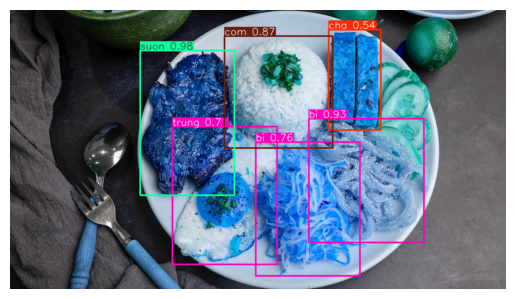

In [4]:
# Perform predictions on an image
results = model.predict(
    source='https://static.hawonkoo.vn/hwk02/images/2023/10/com-tam-suon-bi-cha-2.jpg',
    conf=0.5  # Confidence threshold
)

# Get the image with bounding boxes annotated
annotated_image = results[0].plot()

# Display the image in Google Colab
plt.imshow(annotated_image)
plt.axis('off')  # Turn off axis display
plt.show()

In [5]:
# Get the list of classes
class_names = model.names
print("List of classes in the YOLO model:")
for i, name in class_names.items():
    print(f"{i}: {name}")

List of classes in the YOLO model:
0: banh da
1: banh gao
2: banh gao cay tokbokki
3: banh hoi
4: banh hoi heo quay
5: banh hu tieu
6: banh mi sandwish
7: banh pho
8: bap
9: bi
10: bun
11: bun bo
12: bun ca
13: bun dau
14: bun hai san
15: bun moc
16: ca
17: ca hoi
18: ca hoi sot pho mai kem
19: cac loai rau cu
20: cha
21: cha ca
22: cha com
23: cha gio
24: com
25: com ca ri
26: com chien cai xoan
27: com ga
28: com suon
29: com suon bi cha
30: com suon bi cha trung
31: com suon bi trung
32: com suon cha
33: com suon trung
34: dau hu
35: doi sun
36: dua chua
37: ga ran va khoai tay chien
38: gan
39: hu tieu
40: hu tieu mi
41: khoai tay chien
42: mi
43: mi ga hung que kem
44: mi jajangmyeon
45: mi misoramen
46: mi nuoc sup bun bo
47: mi quang
48: mi tron
49: mi tuong den Jajangmyeon
50: muc
51: naruto
52: pho bo
53: pho ga
54: pho mai
55: rau ram
56: soi mi khoai lang
57: soi mi miso
58: sot tuong den
59: suon
60: thit bam
61: thit bo
62: thit ga
63: thit heo
64: thit heo chien xu tonkat